In [2]:
import pandas as pd
import numpy as np

In [3]:
# 1. Adatok beolvasása és idősorba rendezése
df = pd.read_csv('mock_data/processed_articles.csv')
df['datum'] = pd.to_datetime(df['datum'])
df = df.sort_values(by='datum')
df_indexed = df.set_index('datum')

In [4]:
# 2. A Z-score számoló logika (14 napos mozgóátlaggal)
window_size = 14

In [5]:
def calculate_z_score(group):
    # Kiszámoljuk az utolsó 14 nap átlagát és szórását
    rolling_mean = group['sentiment_score'].rolling(window=f'{window_size}D', min_periods=1).mean()
    rolling_std = group['sentiment_score'].rolling(window=f'{window_size}D', min_periods=1).std()
    # Nullával osztás elkerülése
    rolling_std = rolling_std.replace(0, np.nan).fillna(1.0)
        # Értékek rögzítése és a Z-score képlet alkalmazása
    group['rolling_mean'] = rolling_mean.values
    group['rolling_std'] = rolling_std.values
    group['z_score'] = (group['sentiment_score'] - group['rolling_mean']) / group['rolling_std']
    
    return group

In [6]:
# 3. Csoportosítás portál és politikus szerint, majd a matek ráküldése
df_calculated = df_indexed.groupby(['portal_nev', 'emlitett_szemely'], group_keys=False).apply(calculate_z_score)

/tmp/ipykernel_24/3705093055.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_calculated = df_indexed.groupby(['portal_nev', 'emlitett_szemely'], group_keys=False).apply(calculate_z_score)


In [7]:
# 4. Eredmény: Kikészítjük a legnagyobb anomáliákat
df_anomalies = df_calculated.sort_values(by='z_score', key=abs, ascending=False)
display_cols = ['portal_nev', 'emlitett_szemely', 'sentiment_score', 'rolling_mean', 'z_score']
display(df_anomalies[display_cols].head(15))

,portal_nev,emlitett_szemely,sentiment_score,rolling_mean,z_score
datum,,,,,
2026-02-27 12:46:05.398077,ORIGO,MP,0.7541,-0.580312,2.399571
2026-02-28 20:44:05.408279,ORIGO,MP,0.6789,-0.582870,2.261377
2026-02-22 09:10:05.408279,ATV,MP,-0.9749,0.153667,-2.147042
2026-02-14 14:09:05.398077,RTL,MP,0.9796,-0.122760,2.072391
2026-02-22 10:20:05.408279,HVG,MP,-0.7239,0.164516,-2.070602
2026-02-06 08:26:05.409394,NAPI,MP,-0.9718,-0.005871,-2.055903
2026-02-11 05:11:05.398077,ORIGO,OV,-0.9347,0.124332,-2.041083
2026-02-20 07:46:05.409394,444,MP,0.9148,-0.207549,2.037495
2026-02-12 11:37:05.398077,RTL,MP,0.7964,-0.170731,2.036084


In [8]:
#Elérés (Reach) adatok beolvasása és összekapcsolása (Join)
df_outlets = pd.read_csv('mock_data/media_outlets.csv')

# Visszaállítjuk az indexet, hogy a 'datum' ismét normál oszlop legyen az összekapcsoláshoz
df_reset = df_calculated.reset_index()

# Bal oldali összekapcsolás a portál neve alapján
df_merged = pd.merge(df_reset, df_outlets, on='portal_nev', how='left')

# Ellenőrizzük, hogy rendben bekerült-e a 'becsult_eleres' oszlop
display(df_merged[['datum', 'portal_nev', 'emlitett_szemely', 'z_score', 'becsult_eleres']].head())

,datum,portal_nev,emlitett_szemely,z_score,becsult_eleres
0,2026-01-31 14:52:05.398077,PESTI_SRACOK,MP,0.0,608123
1,2026-01-31 14:57:05.408279,ATV,MP,0.0,1441914
2,2026-01-31 15:04:05.408279,INDEX,OV,0.0,1278025
3,2026-01-31 15:19:05.398077,MAGYAR_NEMZET,MP,0.0,62883
4,2026-01-31 15:26:05.409394,TELEX,MP,0.0,733388


In [9]:
#A valós hatás (Impact Score) számítása logaritmikus súlyozással

# Kiszámoljuk az Impact pontszámot. Adunk 1-et az eléréshez, hogy elkerüljük a log(0) hibát, ha valaminek 0 lenne az elérése.
df_merged['impact_score'] = df_merged['z_score'] * np.log10(df_merged['becsult_eleres'] + 1)

# Rendezzük a táblázatot a legnagyobb valós hatást kiváltó cikkek szerint (abszolút érték alapján)
df_final_impact = df_merged.sort_values(by='impact_score', key=abs, ascending=False)

# Nézzük meg az új top 10 listát!
display_cols_final = ['datum', 'portal_nev', 'emlitett_szemely', 'z_score', 'becsult_eleres', 'impact_score']
display(df_final_impact[display_cols_final].head(10))

,datum,portal_nev,emlitett_szemely,z_score,becsult_eleres,impact_score
1434,2026-02-22 09:10:05.408279,ATV,MP,-2.147042,1441914,-13.223505
1817,2026-02-27 12:46:05.398077,ORIGO,MP,2.399571,283247,13.082862
1436,2026-02-22 10:20:05.408279,HVG,MP,-2.070602,1110033,-12.517484
925,2026-02-14 14:09:05.398077,RTL,MP,2.072391,1024000,12.455693
1894,2026-02-28 20:44:05.408279,ORIGO,MP,2.261377,283247,12.329402
777,2026-02-12 11:37:05.398077,RTL,MP,2.036084,1024000,12.237474
1394,2026-02-21 15:50:05.398077,RTL,OV,2.034407,1024000,12.227399
371,2026-02-06 08:26:05.409394,NAPI,MP,-2.055903,613984,-11.899891
1308,2026-02-20 06:33:05.398077,RTL,OV,1.979169,1024000,11.895399
1310,2026-02-20 07:46:05.409394,444,MP,2.037495,567282,11.723337


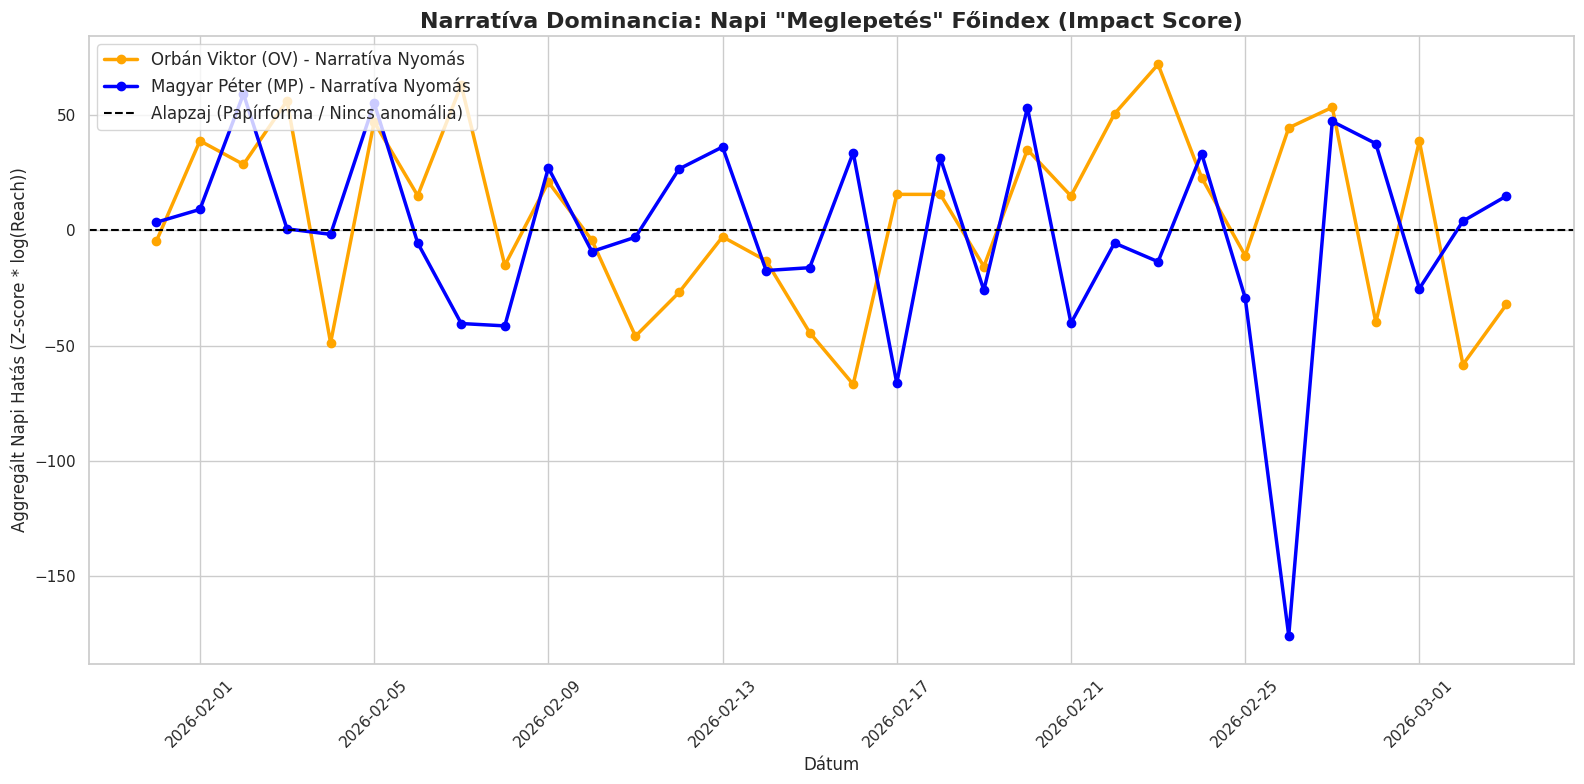

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Profibb vizuális stílus beállítása
sns.set_theme(style="whitegrid")

# 1. Napi aggregáció: összegezzük a 'valós hatást' (Impact Score) naponta és politikusok szerint
# Létrehozunk egy tiszta dátum oszlopot (órák és percek nélkül)
df_final_impact['csak_datum'] = df_final_impact['datum'].dt.date

# Kiforgatjuk a táblázatot, hogy az OV és MP külön oszlopba kerüljön, napokra lebontva
daily_impact = df_final_impact.groupby(['csak_datum', 'emlitett_szemely'])['impact_score'].sum().unstack().fillna(0)

# 2. A grafikon megrajzolása
plt.figure(figsize=(16, 8))

# Vonalak kirajzolása a két politikusnak
if 'OV' in daily_impact.columns:
    plt.plot(daily_impact.index, daily_impact['OV'], label='Orbán Viktor (OV) - Narratíva Nyomás', color='orange', linewidth=2.5, marker='o')
if 'MP' in daily_impact.columns:
    plt.plot(daily_impact.index, daily_impact['MP'], label='Magyar Péter (MP) - Narratíva Nyomás', color='blue', linewidth=2.5, marker='o')

# Nullás alapvonal (Ez jelképezi a "megszokott" zajt)
plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label='Alapzaj (Papírforma / Nincs anomália)')

# Címkék és dizájn
plt.title('Narratíva Dominancia: Napi "Meglepetés" Főindex (Impact Score)', fontsize=16, fontweight='bold')
plt.xlabel('Dátum', fontsize=12)
plt.ylabel('Aggregált Napi Hatás (Z-score * log(Reach))', fontsize=12)
plt.legend(fontsize=12, loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

# Megjelenítés
plt.show()